Import Libraries

In [64]:
import pandas as pd
import numpy as py
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings("ignore")

Import Dataset

In [2]:
df = pd.read_csv("simulated-data-raw1.csv")

Understanding Data

In [3]:
df.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0


In [4]:
df.sample(10)

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
281967,281967,281967,2024-05-29 17:15:24,1876,4356,24.18,5073324,58,0,0
31361,31361,31361,2024-04-07 13:18:43,118,599,175.01,566323,6,0,0
212642,212642,212642,2024-05-15 10:38:47,1249,1873,30.93,3839927,44,0,0
337765,337765,337765,2024-06-10 12:44:23,2396,1681,6.28,6093863,70,0,0
82804,82804,82804,2024-04-18 09:55:47,2222,4155,57.60,1504547,17,0,0
94623,94623,94623,2024-04-20 17:10:06,2259,1143,4.02,1703406,19,0,0
188920,188920,188920,2024-05-10 11:34:18,1699,1821,44.14,3411258,39,0,0
354180,354180,354180,2024-06-14 00:38:50,1688,2426,44.77,6395930,74,0,0
197417,197417,197417,2024-05-12 08:14:16,711,3064,88.41,3572056,41,0,0
177859,177859,177859,2024-05-08 06:21:42,2090,907,60.87,3219702,37,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 383087 entries, 0 to 383086
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         383087 non-null  int64  
 1   TRANSACTION_ID     383087 non-null  int64  
 2   TX_DATETIME        383087 non-null  object 
 3   CUSTOMER_ID        383087 non-null  int64  
 4   TERMINAL_ID        383087 non-null  int64  
 5   TX_AMOUNT          383087 non-null  float64
 6   TX_TIME_SECONDS    383087 non-null  int64  
 7   TX_TIME_DAYS       383087 non-null  int64  
 8   TX_FRAUD           383087 non-null  int64  
 9   TX_FRAUD_SCENARIO  383087 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 29.2+ MB


In [6]:
df.describe()

,Unnamed: 0,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
count,383087.000000,383087.000000,383087.000000,383087.000000,383087.000000,3.830870e+05,383087.000000,383087.000000,383087.000000
mean,191543.000000,191543.000000,1250.086142,2498.017630,54.166366,3.457548e+06,39.518498,0.015054,0.034535
std,110587.835624,110587.835624,720.353354,1447.598131,45.600638,1.994220e+06,23.080303,0.121768,0.286666
min,0.000000,0.000000,0.000000,0.000000,0.000000,3.100000e+01,0.000000,0.000000,0.000000
25%,95771.500000,95771.500000,627.000000,1240.000000,21.220000,1.742742e+06,20.000000,0.000000,0.000000
50%,191543.000000,191543.000000,1250.000000,2497.000000,44.850000,3.456763e+06,40.000000,0.000000,0.000000
75%,287314.500000,287314.500000,1871.000000,3755.000000,77.290000,5.177722e+06,59.000000,0.000000,0.000000
max,383086.000000,383086.000000,2499.000000,4999.000000,4016.500000,6.911981e+06,79.000000,1.000000,3.000000


In [7]:
df["TX_FRAUD"].value_counts()

TX_FRAUD
0    377320
1      5767
Name: count, dtype: int64

In [8]:
df["TX_FRAUD_SCENARIO"].value_counts()

TX_FRAUD_SCENARIO
0    377320
2      3681
3      1891
1       195
Name: count, dtype: int64

In [9]:
df.isnull().sum()

Unnamed: 0           0
TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

Data Cleaning

In [10]:
df_clean = df
df_clean.head()

,Unnamed: 0,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,0,2024-04-01 00:00:31,596,1337,57.16,31,0,0,0
1,1,1,2024-04-01 00:07:56,2,523,146.00,476,0,0,0
2,2,2,2024-04-01 00:10:34,927,824,50.99,634,0,0,0
3,3,3,2024-04-01 00:10:45,568,4805,44.71,645,0,0,0
4,4,4,2024-04-01 00:13:44,541,3260,59.07,824,0,0,0


In [26]:
import sqlite3

# SQL
df_test = df.copy()
conn = sqlite3.connect(':memory:')

# Save DataFrame to the database as a table called 'transactions'
df_test.to_sql('transactions', conn, index=False, if_exists='replace')

# SQL query to add transactions in last hour, and amount in last hour per customer
query = """
SELECT
    t1.*,
    COUNT(t2.TX_AMOUNT) AS TXs_LAST_1H,
    COALESCE(SUM(t2.TX_AMOUNT), 0) AS AMOUNT_LAST_1H
FROM transactions t1
LEFT JOIN transactions t2
    ON t1.CUSTOMER_ID = t2.CUSTOMER_ID
    AND t2.TX_TIME_SECONDS BETWEEN t1.TX_TIME_SECONDS - 3600 AND t1.TX_TIME_SECONDS
GROUP BY t1.ROWID
"""

# Run the query
df_clean = pd.read_sql_query(query, conn)
conn.close()


In [ ]:
# calc standard deviation ,to know if a customer normally has spread out diferrent amounts in transactions or not
# (if else) bec std needs atleast 2 inputs
def fun(group):
    if len(group)>1:
        return round(group["TX_AMOUNT"].std(), 2)
    return 0.0

# use reset_index to fix mult-index issue with groupby
df_clean["CUSTOMER_STD"] = df_clean.groupby("CUSTOMER_ID").apply(fun).reset_index(level=0, drop=True).round(2)
df_clean["CUSTOMER_STD"].fillna(0.0, inplace=True)

df_clean.head()

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG,IS_NIGHT,IS_WEEKEND,TERMINAL_RISK,TXs_LAST_1H,AMOUNT_LAST_1H
0,0,596,1337,57.16,31,0,0,0,27.50,0.51,1.33,0,1,0,1,0,0.000000,1,57.16
1,1,2,523,146.00,476,0,0,0,47.90,1.28,1.72,0,1,0,1,0,0.000000,1,146.00
2,2,927,824,50.99,634,0,0,0,58.69,-0.06,0.94,0,1,0,1,0,0.000000,1,50.99
3,3,568,4805,44.71,645,0,0,0,4.85,2.62,1.40,0,1,0,1,0,0.011628,1,44.71
4,4,541,3260,59.07,824,0,0,0,76.46,0.19,1.33,0,1,0,1,0,0.000000,1,59.07


In [28]:
# calc z-score to cheack if customer transaction is sus according to its std (std column may not be very usefull after this)
def fun(group):
    z_score = (group["TX_AMOUNT"] - group["TX_AMOUNT"].mean()) / group["CUSTOMER_STD"]
    return z_score

df_clean["Z_SCORE"] = df_clean.groupby("CUSTOMER_ID").apply(fun).reset_index(level=0, drop=True).round(2)
df_clean["Z_SCORE"].fillna(0.0, inplace=True)

df_clean.head()

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG,IS_NIGHT,IS_WEEKEND,TERMINAL_RISK,TXs_LAST_1H,AMOUNT_LAST_1H
0,0,596,1337,57.16,31,0,0,0,27.50,0.51,1.33,0,1,0,1,0,0.000000,1,57.16
1,1,2,523,146.00,476,0,0,0,47.90,1.28,1.72,0,1,0,1,0,0.000000,1,146.00
2,2,927,824,50.99,634,0,0,0,58.69,-0.06,0.94,0,1,0,1,0,0.000000,1,50.99
3,3,568,4805,44.71,645,0,0,0,4.85,2.62,1.40,0,1,0,1,0,0.011628,1,44.71
4,4,541,3260,59.07,824,0,0,0,76.46,0.19,1.33,0,1,0,1,0,0.000000,1,59.07


In [ ]:
# add amount to avg ratio
def fun(group):
    return group["TX_AMOUNT"] / group["TX_AMOUNT"].mean()

df_clean["AMOUNT_TO_AVG_RATIO"] = df_clean.groupby("CUSTOMER_ID").apply(fun).reset_index(level=0, drop=True).round(2)

df_clean.head()

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG,IS_NIGHT,IS_WEEKEND,TERMINAL_RISK,TXs_LAST_1H,AMOUNT_LAST_1H
0,0,596,1337,57.16,31,0,0,0,27.50,0.51,1.33,0,1,0,1,0,0.000000,1,57.16
1,1,2,523,146.00,476,0,0,0,47.90,1.28,1.72,0,1,0,1,0,0.000000,1,146.00
2,2,927,824,50.99,634,0,0,0,58.69,-0.06,0.94,0,1,0,1,0,0.000000,1,50.99
3,3,568,4805,44.71,645,0,0,0,4.85,2.62,1.40,0,1,0,1,0,0.011628,1,44.71
4,4,541,3260,59.07,824,0,0,0,76.46,0.19,1.33,0,1,0,1,0,0.000000,1,59.07


In [ ]:
# temporary to use later
df_clean["Week"] = df_clean["TX_TIME_DAYS"] // 7
df_clean["Month"] = df_clean["TX_TIME_DAYS"] // 30

In [ ]:
# amount to avg for differnet periods per customer
df_clean["AMOUNT_TO_AVG_DAY"] = df_clean.groupby(["CUSTOMER_ID","TX_TIME_DAYS"]) \
                                 .apply(lambda x: x["TX_AMOUNT"] / x["TX_AMOUNT"].mean()).reset_index(level=0, drop=True).round(2)   
df_clean["AMOUNT_TO_AVG_WEEK"] = df_clean.groupby(["CUSTOMER_ID","Week"]) \
                                 .apply(lambda x: x["TX_AMOUNT"] / x["TX_AMOUNT"].mean()).reset_index(level=0, drop=True).round(2)   
df_clean["AMOUNT_TO_AVG_MONTH"] = df_clean.groupby(["CUSTOMER_ID","MONTH"]) \
                                 .apply(lambda x: x["TX_AMOUNT"] / x["TX_AMOUNT"].mean()).reset_index(level=0, drop=True).round(2)   

In [ ]:
# number of transactions for different periods per customer 
df_clean["TX_TIMES_DAY"] = df_clean.groupby(["CUSTOMER_ID","TX_TIME_DAYS"]) \
                                 .count().reset_index(level=0, drop=True)   
df_clean["TX_TIMES_WEEK"] = df_clean.groupby(["CUSTOMER_ID","Week"]) \
                                 .count().reset_index(level=0, drop=True).round(2)   
df_clean["TX_TIMES_MONTH"] = df_clean.groupby(["CUSTOMER_ID","MONTH"]) \
                                 .count().reset_index(level=0, drop=True).round(2)   

In [ ]:
df_clean.drop(columns=["Month", "Week"], axis=1 ,inplace=True)

In [30]:
df_clean.sample(10)

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG,IS_NIGHT,IS_WEEKEND,TERMINAL_RISK,TXs_LAST_1H,AMOUNT_LAST_1H
7170,7170,400,2586,44.99,129709,1,0,0,0.0,inf,1.27,12,2,1,0,0,0.282051,1,44.99
310925,310925,2020,36,7.48,5601737,64,0,0,0.0,-inf,0.99,20,2,0,0,0,0.000000,1,7.48
355987,355987,2141,1448,61.76,6430549,74,0,0,0.0,inf,1.01,10,5,1,0,1,0.000000,2,104.04
195115,195115,2340,1588,59.16,3511813,40,0,0,0.0,-inf,0.67,15,6,0,0,1,0.026316,2,221.19
375979,375979,29,1369,85.00,6783256,78,0,0,0.0,-inf,0.93,12,2,1,0,0,0.000000,1,85.00
380742,380742,714,2141,11.24,6869209,79,0,0,0.0,-inf,0.14,12,3,1,0,0,0.000000,2,166.73
114534,114534,2241,725,41.47,2060798,23,0,0,0.0,inf,1.09,20,3,1,0,0,0.000000,1,41.47
313063,313063,475,1352,49.49,5654345,65,0,0,0.0,-inf,0.90,10,3,0,0,0,0.023810,1,49.49
156587,156587,570,2038,134.60,2819045,32,0,0,0.0,inf,1.55,15,5,0,0,1,0.000000,2,245.78
166452,166452,2318,2307,113.53,2996997,34,0,0,0.0,inf,1.53,16,7,1,0,1,0.000000,1,113.53


In [ ]:
# Convert to datetime
df_clean["TX_DATETIME"] = pd.to_datetime(df_clean["TX_DATETIME"])

# Now extract hour of transaction 
# And day of week of transaction starting from (sunday = 1,... saturday = 7)
df_clean["TX_HOUR"] = df_clean["TX_DATETIME"].dt.hour
df_clean["TX_DAY"] = df_clean["TX_DATETIME"].dt.dayofweek + 1

In [ ]:
# flag for if terminal used is not the same as previous one
df_clean['NEW_TERMINAL_FLAG'] = df_clean.groupby('CUSTOMER_ID')['TERMINAL_ID'].apply(lambda x: x != x.shift()).astype(int)

In [18]:
# making temp column unique terminal count in same hour same day
df_clean['unique_terminal_count'] = df_clean.groupby(['CUSTOMER_ID', 'TX_HOUR', 'TX_DAY'])['TERMINAL_ID'].transform('nunique')

df_clean['MULTI_TERMINAL_FLAG'] = (df_clean['unique_terminal_count'] >= 3).reset_index(drop=True).astype(int)
df_clean.drop(columns='unique_terminal_count', axis=1, inplace=True)

In [19]:
# Drop columns
df_clean.drop(columns=["Unnamed: 0", "TX_DATETIME"] ,axis=1 , inplace=True)
df_clean.sample(5)

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG
193047,193047,237,458,36.58,3489827,40,0,0,0.0,inf,1.38,9,6,1
181322,181322,377,1250,4.91,3262705,37,0,0,0.0,-inf,0.49,18,3,0
132959,132959,1919,3775,10.11,2394000,27,0,0,0.0,-inf,0.90,17,7,0
89888,89888,201,2244,131.32,1616622,18,0,0,0.0,inf,1.39,17,5,0
362883,362883,1677,3796,97.88,6540231,75,0,0,0.0,inf,1.32,16,6,0


In [20]:
# Adding is_night column (from 11 pm to 6 am) and is_weekend column (5,6,7 => weekend)
df_clean["IS_NIGHT"] = ((df_clean['TX_HOUR'] == 23) | ((df_clean['TX_HOUR'] >= 0) & (df_clean['TX_HOUR'] <= 6))).astype(int)
df_clean["IS_WEEKEND"] = (df_clean['TX_DAY'] > 4).astype(int)

df_clean.head()

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG,IS_NIGHT,IS_WEEKEND
0,0,596,1337,57.16,31,0,0,0,27.50,0.51,1.33,0,1,0,1,0
1,1,2,523,146.00,476,0,0,0,47.90,1.28,1.72,0,1,0,1,0
2,2,927,824,50.99,634,0,0,0,58.69,-0.06,0.94,0,1,0,1,0
3,3,568,4805,44.71,645,0,0,0,4.85,2.62,1.40,0,1,0,1,0
4,4,541,3260,59.07,824,0,0,0,76.46,0.19,1.33,0,1,0,1,0


In [ ]:
# add a risk score
df["TERMINAL_RISK"] = df.groupby("TERMINAL_ID")["TX_FRAUD"].transform(lambda x: x.sum() / len(x))

In [24]:
df_clean.sample(10)

,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,CUSTOMER_STD,Z_SCORE,AMOUNT_TO_AVG_RATIO,TX_HOUR,TX_DAY,MULTI_TERMINAL_FLAG,IS_NIGHT,IS_WEEKEND,TERMINAL_RISK
102975,102975,1874,258,10.23,1861136,21,0,0,0.0,-inf,0.60,12,1,1,0,0,0.000000
45317,45317,1930,1704,28.74,821748,9,0,0,0.0,-inf,0.46,12,3,0,0,0,0.010000
290835,290835,1371,2843,37.75,5238723,60,0,0,0.0,-inf,0.44,15,5,0,0,1,0.024691
165447,165447,1753,3957,86.39,2984594,34,0,0,0.0,inf,1.03,13,7,0,0,1,0.000000
84428,84428,1480,2223,43.49,1520867,17,0,0,0.0,inf,1.36,14,4,0,0,0,0.011628
10901,10901,718,3948,50.30,204040,2,0,0,0.0,inf,1.32,8,3,1,0,0,0.000000
341988,341988,418,2475,91.03,6174299,71,0,0,0.0,-inf,0.95,11,2,1,0,0,0.009709
119720,119720,460,54,6.58,2170600,25,0,0,0.0,-inf,0.29,2,5,0,1,1,0.000000
330494,330494,2376,1642,3.20,5973320,69,0,0,0.0,-inf,0.11,3,7,1,1,1,0.000000
84550,84550,918,2218,9.31,1522263,17,0,0,0.0,inf,1.76,14,4,0,0,0,0.000000


Plotting the data to get clear insights

Text(0.5, 1.0, 'The Fraud Transactions are 1.51% of the dataset')

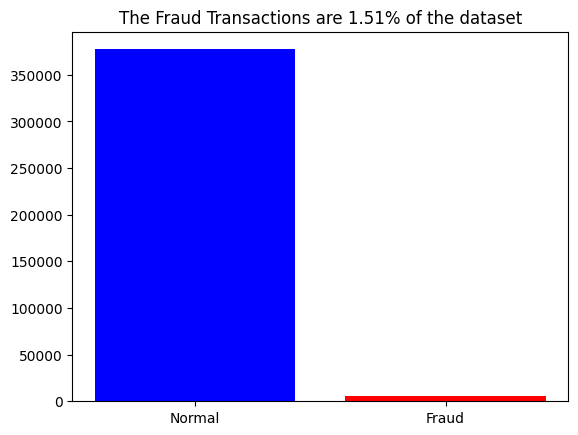

In [94]:
Normal_len = len(df[df["TX_FRAUD"]==0])
Fraud_len = len(df[df["TX_FRAUD"]==1])

plt.bar([0 ,1], [Normal_len, Fraud_len], color=['b' ,'r'])
plt.xticks([0, 1], ["Normal", "Fraud"])

t = round((Fraud_len/len(df) * 100),2)
plt.title(f"The Fraud Transactions are {t}% of the dataset")

<Axes: >

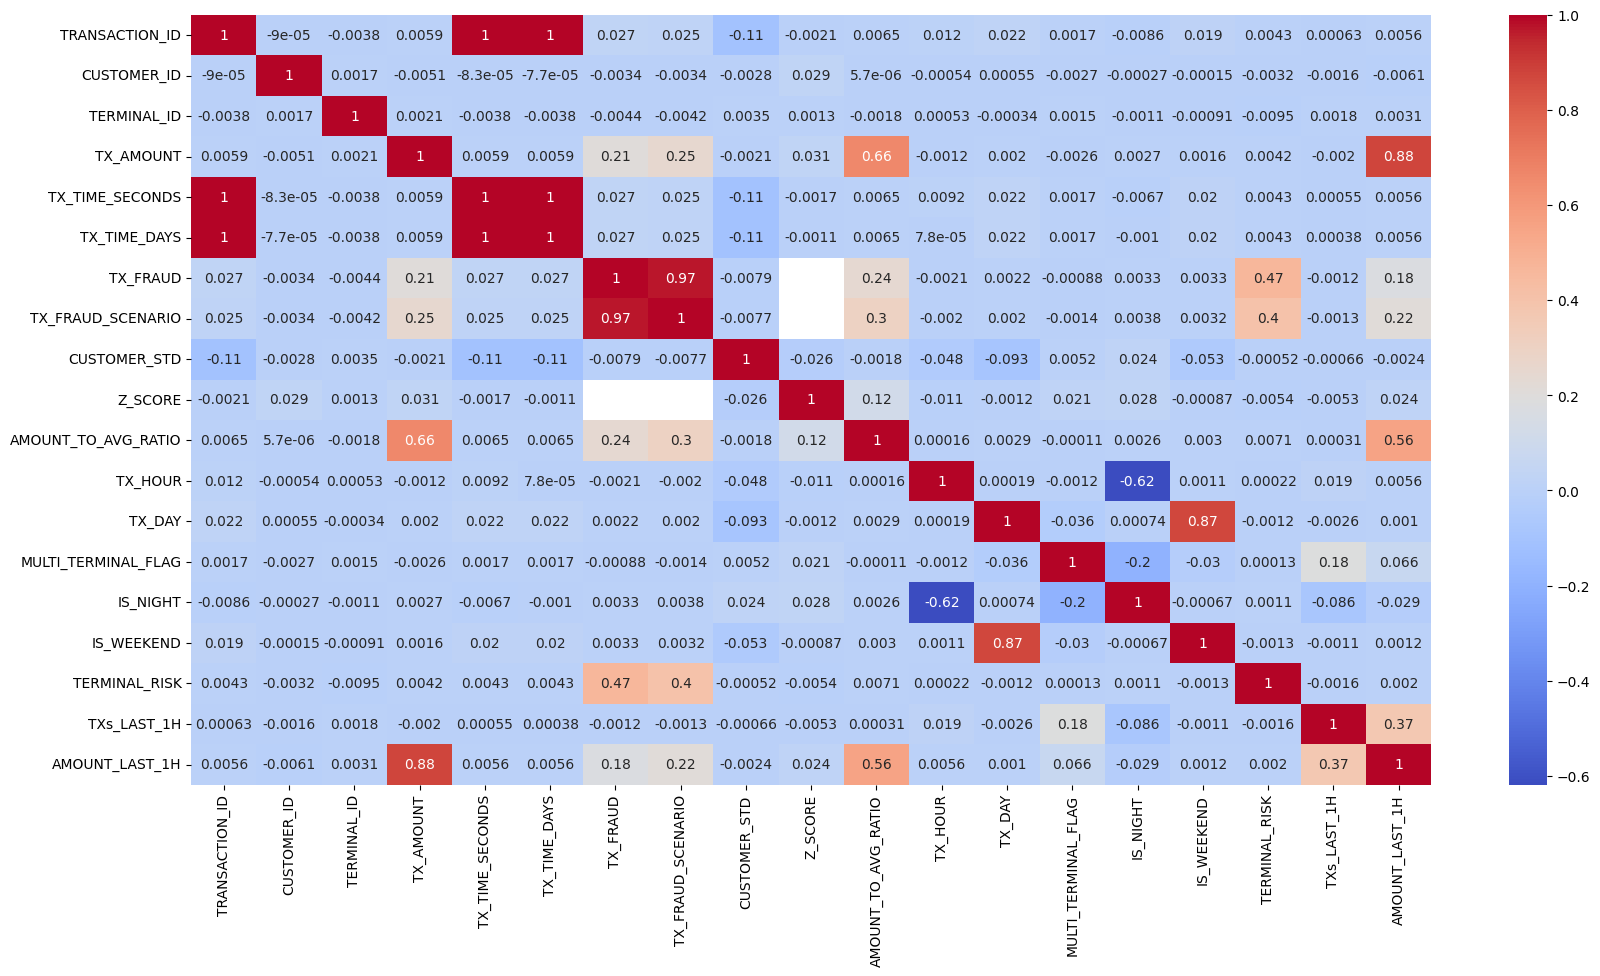

In [40]:
plt.figure(figsize=(20, 10))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, cmap="coolwarm")

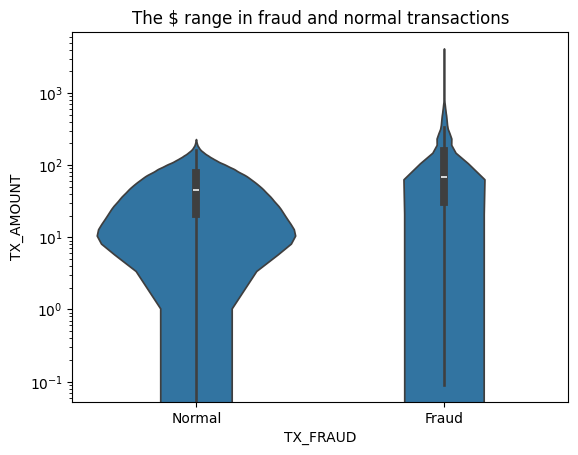

In [95]:
sns.violinplot(x='TX_FRAUD', y='TX_AMOUNT',  data=df_clean)
plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yscale("log")
plt.title("The $ range in fraud and normal transactions")
plt.show()

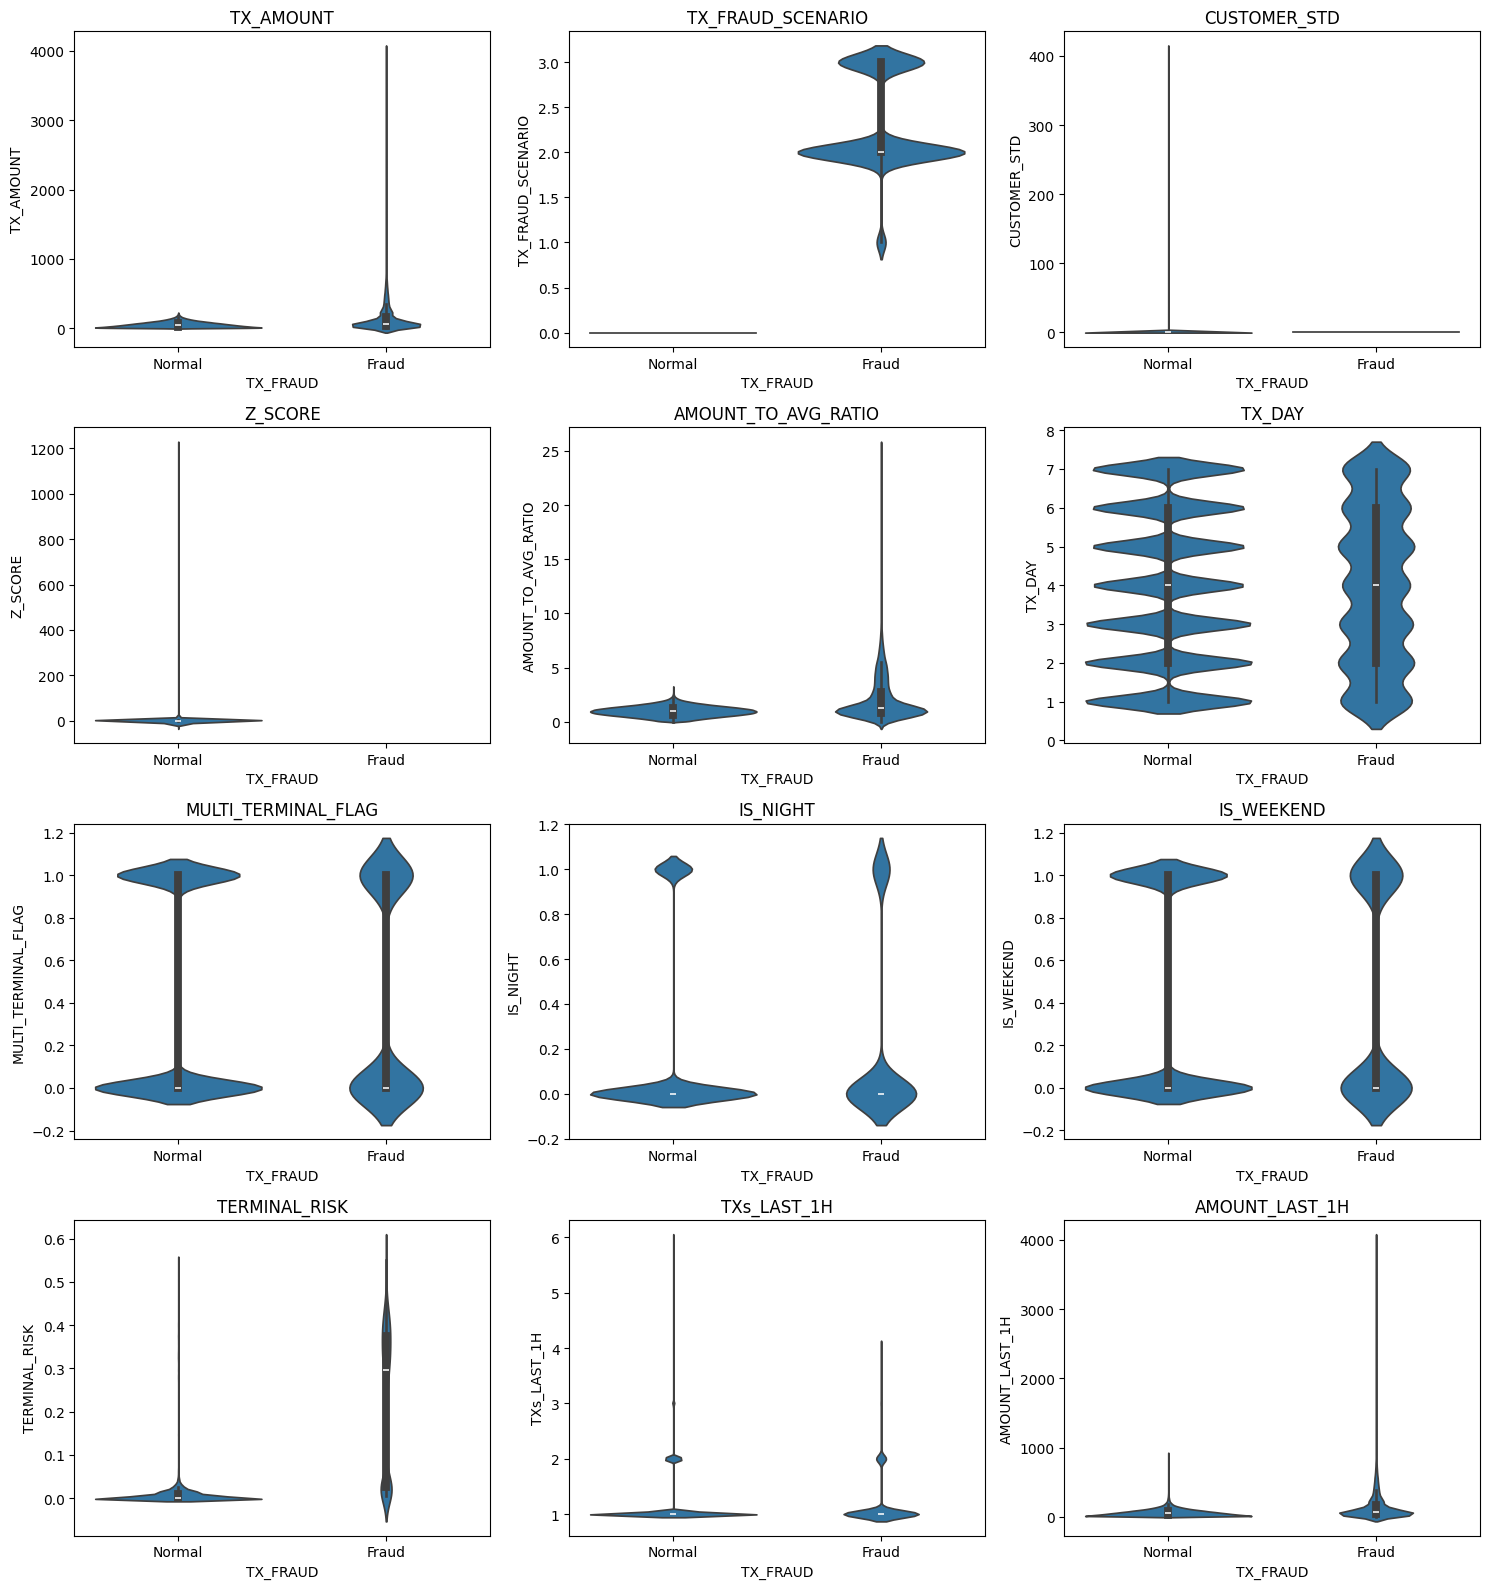

In [75]:
# Columns to exclude
exclude_cols = ["TX_FRAUD", "CUSTOMER_ID", "TRANSACTION_ID", "TX_TIME_SECONDS", "TX_TIME_DAYS", "TERMINAL_ID", "TX_HOUR"]

# Columns to plot
plot_cols = [col for col in df_clean.columns if col not in exclude_cols]
col_count = len(plot_cols)

# Grid size
cols = 3
rows = math.ceil(col_count / cols)

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4 * rows))
axes = axes.flatten()

# Plot each violin
for i, col in enumerate(plot_cols):
    sns.violinplot(data=df_clean, x="TX_FRAUD", y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(["Normal", "Fraud"])

# Remove unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


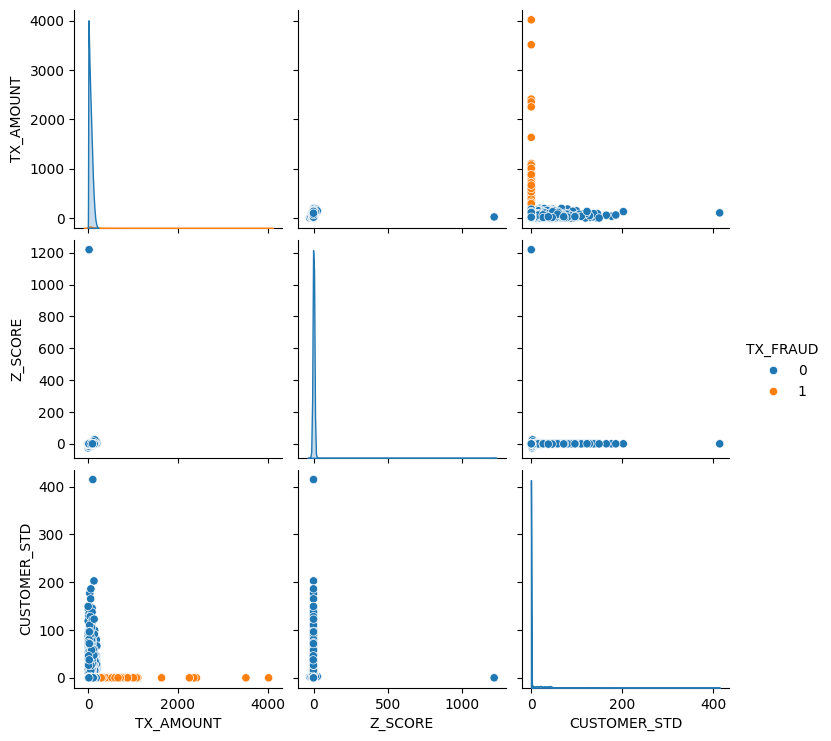

In [56]:
sns.pairplot(df[['TX_AMOUNT', 'Z_SCORE', 'CUSTOMER_STD', 'TX_FRAUD']], hue='TX_FRAUD')

In [ ]:
df_clean.to_csv('DataCleaned')